In [1]:
import sys
print(sys.executable)

c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Scripts\python.exe


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
#this to read the dataset
df=pd.read_csv("heart_disease_dataset.csv")
#this to show the first 5 rows of the dataset
df.head()
print("dataset shape:", df.shape)
#this to show the information of the dataset
df.info()
print("missing values per column:")
#this to show the missing values per column
print(df.isnull().sum())
#for the values of ca and thal the null values are over than 50% to 70% so we need to drop them bcz they will introduce bias in the model
df_clean=df.drop(columns=["ca","thal"]).copy()
print("cleaned dataset shape:", df_clean.shape)
print("missing values in cleaned dataset:")
print(df.isnull().sum())

dataset shape: (920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0


cleaned dataset shape: (920, 14)
missing values in cleaned dataset:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
target        0
dtype: int64
target value counts:
target
1    509
0    411
Name: count, dtype: int64


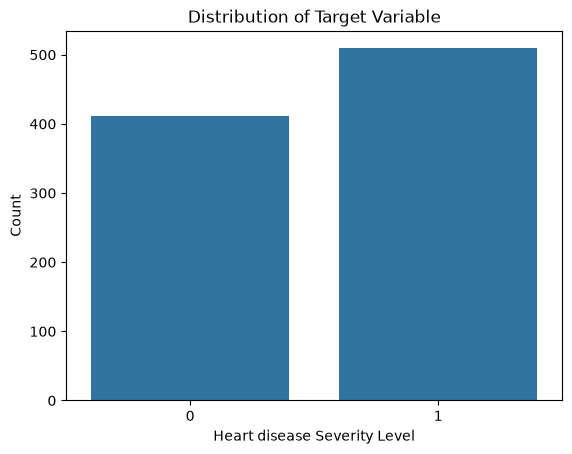

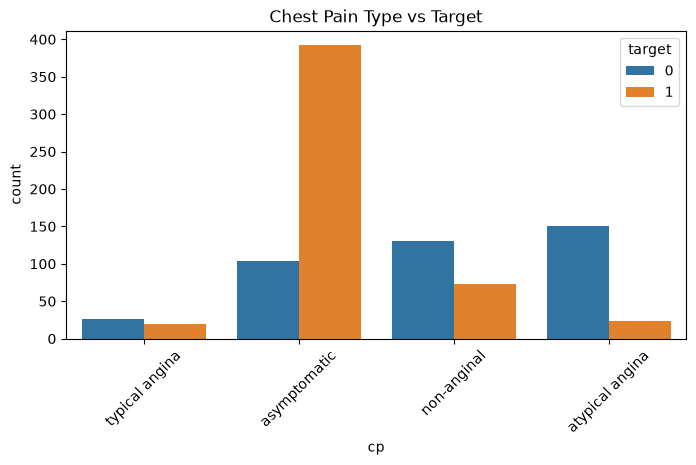

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
#this to read the dataset
df=pd.read_csv("heart_disease_dataset.csv")
df_clean=df.drop(columns=["ca","thal"]).copy()
#ok now for the target values are 0,1,2... the number of heart attacks so we need to convert them to binary values 0 and 1 so we will consider the values of 0 as no heart attack and the values of 1,2,3,4 as heart attack so we will convert them to 1
df_clean['target'] = df_clean["num"].apply(lambda x: 1 if x > 0 else 0)
df_clean=df_clean.drop(columns=['num'])
print("cleaned dataset shape:", df_clean.shape)
print("missing values in cleaned dataset:")
print(df_clean.isnull().sum())


#i will drop the id bcz had no predictive power
df_clean=df_clean.drop(columns=['id'])
#as the threstbsp and chol can't be 0 so i will change them with NaN
df_clean['trestbps'] = df_clean['trestbps'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)
#now this nan values will be filled with the median of the column
df_clean=df_clean.fillna(df_clean.median(numeric_only=True))
df_clean.describe()
print("target value counts:")
print(df_clean['target'].value_counts())
#visualize the distribution of the target variable
sns.countplot(x='target', data=df_clean)
plt.title('Distribution of Target Variable')
plt.xlabel('Heart disease Severity Level')
plt.ylabel('Count')
plt.show()
#Compare Chest Pain Type (cp) against Target 
plt.figure(figsize=(8, 4))
sns.countplot(x='cp', hue='target', data=df_clean)
plt.title('Chest Pain Type vs Target')
plt.xticks(rotation=45)
plt.show()
df_clean.to_csv("cleaned_heart_disease_dataset.csv", index=False)

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv("cleaned_heart_disease_dataset.csv")
df_clean=df.drop(columns=["dataset"]).copy()

categorical_features=df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
df_encoded=pd.get_dummies(df_clean, columns=categorical_features, drop_first=True, dtype=int)
print("encoded dataset shape:", df_encoded.shape)
df_encoded.head(10)
df_encoded.to_csv("encoded_heart_disease_dataset.csv", index=False)


encoded dataset shape: (920, 16)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26164\2392416265.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("encoded_heart_disease_dataset.csv")
x=df.drop(columns=['target'])
y=df['target']
print("features shape:", x.shape)
print("target shape:", y.shape)
print("\nFeature names:", x.columns.tolist())
print("\nTarget distribution:\n", y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

print(x_train.head())
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print("First 5 rows of scaled training data:")
print(x_train_scaled[:5])
print("x_train shape:", x_train_scaled.shape)
print("x_test shape:", x_test_scaled.shape)


features shape: (920, 15)
target shape: (920,)

Feature names: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']

Target distribution:
 target
1    509
0    411
Name: count, dtype: int64
     age  trestbps   chol  thalch  oldpeak  sex_Male  cp_atypical angina  \
640   53     160.0  239.5   122.0      0.0         1                   0   
743   74     130.0  239.5   140.0      0.5         1                   0   
890   53     124.0  243.0   122.0      2.0         1                   0   
270   61     140.0  207.0   138.0      1.9         1                   0   
654   56     155.0  239.5    99.0      0.0         1                   0   

     cp_non-anginal  cp_typical angina  fbs_True  restecg_normal  \
640               1                  0         0               0   
743               1                  0     

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = LogisticRegression(random_state=42)

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores=cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring='accuracy')
print("5 -fold cross-validation accuracy scores")
for i, score in enumerate(cv_scores,1):
    print(f"Fold {i} accuracy: {score*100:.2f}%")
print(f"Mean cross-validation accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)") 

5 -fold cross-validation accuracy scores
Fold 1 accuracy: 76.35%
Fold 2 accuracy: 76.87%
Fold 3 accuracy: 82.31%
Fold 4 accuracy: 80.27%
Fold 5 accuracy: 79.59%
Mean cross-validation accuracy: 79.08% (+/- 2.21%)


Test accuracy: 0.8097826086956522

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.81      0.74      0.78        82
   Heart Disease       0.81      0.86      0.83       102

        accuracy                           0.81       184
       macro avg       0.81      0.80      0.81       184
    weighted avg       0.81      0.81      0.81       184



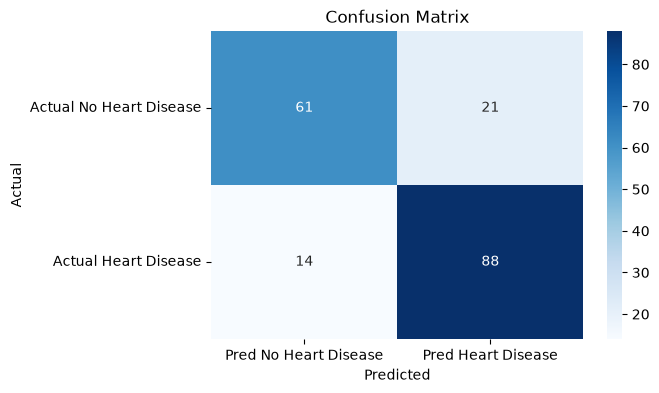

In [7]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
#here we give the model all the training data bcz in the previous step we have already evaluated the model using cross-validation so now we can give it all the training data
model.fit(x_train_scaled, y_train)
#and here we test the predicted targets for the testing data
y_pred=model.predict(x_test_scaled)
#and from here we are evaluating the model
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,target_names=['No Heart Disease', 'Heart Disease']))

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred No Heart Disease', 'Pred Heart Disease'], yticklabels=['Actual No Heart Disease', 'Actual Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  
}
grid=GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train_scaled, y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)
best_model=grid.best_estimator_

Best hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.8043482257767971


c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 

Test accuracy (Custom Threshold): 0.8097826086956522
Classification Report (Custom Threshold):
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.72      0.77        82
   Heart Disease       0.80      0.88      0.84       102

        accuracy                           0.81       184
       macro avg       0.81      0.80      0.80       184
    weighted avg       0.81      0.81      0.81       184



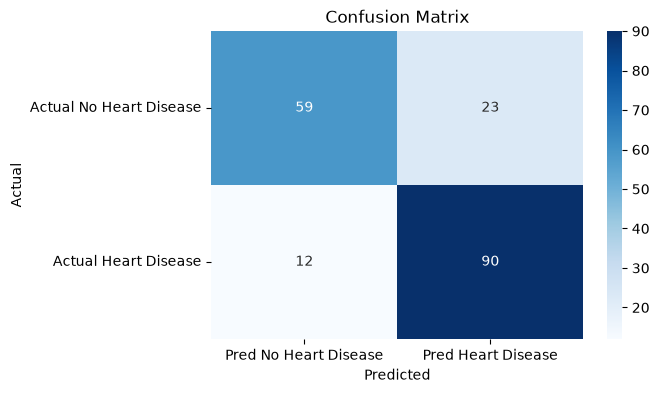

In [17]:
import numpy as np
from sklearn.metrics import classification_report
y_probs = best_model.predict_proba(x_test_scaled)[:, 1]
custom_threshold = 0.45
y_pred_custom = (y_probs >= custom_threshold).astype(int)
print("Test accuracy (Custom Threshold):", accuracy_score(y_test, y_pred_custom))
print("Classification Report (Custom Threshold):")
print(classification_report(y_test, y_pred_custom,target_names=['No Heart Disease', 'Heart Disease']))
plt.figure(figsize=(6, 4))
cm=confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred No Heart Disease', 'Pred Heart Disease'], yticklabels=['Actual No Heart Disease', 'Actual Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

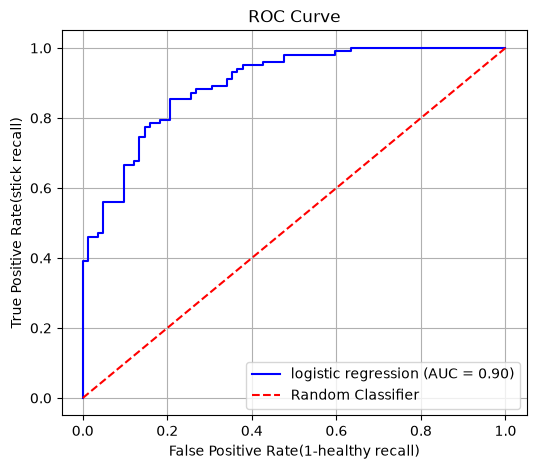

In [18]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
y_probs = best_model.predict_proba(x_test_scaled)[:, 1]
fpr,tpr,thresholds=roc_curve(y_test,y_probs)
auc_score=roc_auc_score(y_test,y_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,color='blue',label=f'logistic regression (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--',label='Random Classifier')
plt.xlabel('False Positive Rate(1-healthy recall)')
plt.ylabel('True Positive Rate(stick recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26164\686520491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')


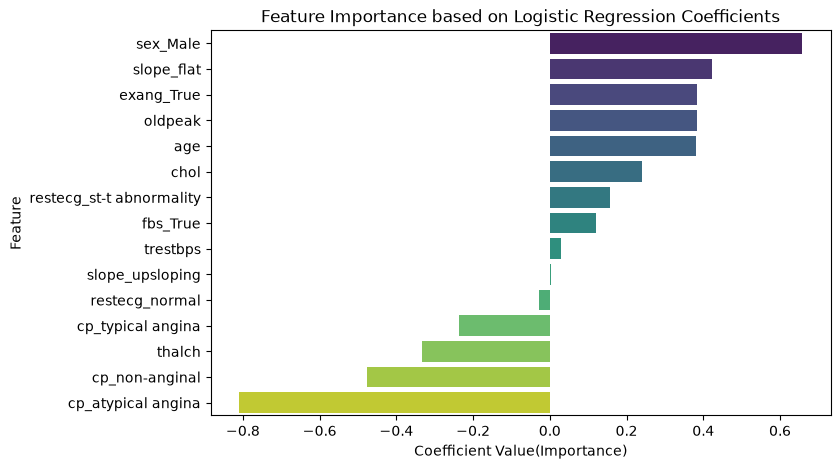

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

coefs=best_model.coef_[0]
feature_names=x.columns

feature_importance_df=pd.DataFrame({'Feature':feature_names,'Importance':coefs}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')
plt.title('Feature Importance based on Logistic Regression Coefficients')
plt.xlabel('Coefficient Value(Importance)')
plt.ylabel('Feature')
plt.show()

In [20]:
import joblib
joblib.dump(best_model, 'best_logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Best logistic regression model and scaler saved successfully.")

Best logistic regression model and scaler saved successfully.


In [26]:
import numpy as np
import pandas as pd
import joblib

loaded_model = joblib.load('best_logistic_regression_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

new_patient = pd.DataFrame([{
    'age': 78,
    'trestbps': 150.0,
    'chol': 200.0,
    'thalch': 50.0,
    'oldpeak': 0.0,
    'sex_Male': 1,
    'cp_atypical angina': 0,
    'cp_non-anginal': 1,
    'cp_typical angina': 0,
    'fbs_True': 0,
    'restecg_normal': 0,
    'restecg_st-t abnormality': 1,
    'exang_True': 0,
    'slope_flat': 1,
    'slope_upsloping': 0
}])

patient_scaled = loaded_scaler.transform(new_patient)
prediction = loaded_model.predict(patient_scaled)[0]
probability = loaded_model.predict_proba(patient_scaled)[0][1]
print(f"Model Prediction: {'Heart Disease / Cardiac Dysfunction' if prediction == 1 else 'Healthy'}")
print(f"Predicted Probability: {probability * 100:.2f}%")

Model Prediction: Heart Disease / Cardiac Dysfunction
Predicted Probability: 92.00%


In [28]:
# app.py
import streamlit as st
import joblib
import pandas as pd

st.title("Heart Disease Risk Predictor")

age = st.number_input("Age", min_value=1, max_value=120, value=50)
trestbps = st.number_input("Resting Blood Pressure (mm Hg)", value=120)
chol = st.number_input("Cholesterol (mg/dL)", value=200)
thalch = st.number_input("Maximum Heart Rate", value=150)
sex_Male = st.selectbox("Sex", ["Female", "Male"]) == "Male"

if st.button("Predict Risk"):
    # Run prediction logic using joblib.load('heart_disease_model.pkl')
    st.write("Prediction complete!")

2026-09-27 15:53:51.739 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.001 
  command:

    streamlit run c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-27 15:53:52.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 15:53:52.0

In [10]:
import pandas as pd
from sklearn.metrics import precision_score,recall_score,f1_score
y_probs = best_model.predict_proba(x_test_scaled)[:, 1]
thresholds=[0.3,0.35,0.4,0.45,0.5,0.55]
results=[]
for threshold in thresholds:
    y_pred_custom = (y_probs >= threshold).astype(int)
    results.append({
        'Threshold': threshold,
        'overall_accuracy': accuracy_score(y_test, y_pred_custom),
        'stick recall': recall_score(y_test, y_pred_custom,pos_label=1),
        'health recall': recall_score(y_test, y_pred_custom,pos_label=0),
        'precision': precision_score(y_test, y_pred_custom,pos_label=1),
        'f1_score': f1_score(y_test, y_pred_custom,pos_label=1)
    })
    df_results=pd.DataFrame(results)
    print(df_results)

   Threshold  overall_accuracy  stick recall  health recall  precision  \
0        0.3          0.804348       0.95098       0.621951   0.757812   

   f1_score  
0  0.843478  


   Threshold  overall_accuracy  stick recall  health recall  precision  \
0       0.30          0.804348      0.950980       0.621951   0.757812   
1       0.35          0.804348      0.931373       0.646341   0.766129   

   f1_score  
0  0.843478  
1  0.840708  
   Threshold  overall_accuracy  stick recall  health recall  precision  \
0       0.30          0.804348      0.950980       0.621951   0.757812   
1       0.35          0.804348      0.931373       0.646341   0.766129   
2       0.40          0.798913      0.892157       0.682927   0.777778   

   f1_score  
0  0.843478  
1  0.840708  
2  0.831050  
   Threshold  overall_accuracy  stick recall  health recall  precision  \
0       0.30          0.804348      0.950980       0.621951   0.757812   
1       0.35          0.804348      0.931373       0.646341   0.766129   
2       0.40          0.798913      0.892157       0.682927   0.777778   
3       0.45          0.809783      0.882353       0.719512   0.796460   

   f1_scor